# 🧠 Second Brain — Life Decision Simulator
## USAII Global AI Hackathon 2026 | Challenge Brief 3 — Direction A
---
**Architecture:**
- **Dataset**: Synthetic + UCI Census life-decision scenarios (8 paths: grad_school, job, startup, bootcamp, freelance, gap_year, nursing, trades)
- **ML Model**: Random Forest + Neural Network for path outcome prediction
- **Deep Learning**: DNN multi-output + Decision Confidence Scorer (archetype alignment)
- **LLM Layer**: Groq LLaMA 3.3 70B for reasoning & tradeoff surfacing
- **Output**: Scored path comparison + hidden tradeoffs + confidence bands

In [1]:
# Cell 1: Install Dependencies
!pip install google-generativeai scikit-learn tensorflow pandas numpy matplotlib seaborn shap flask flask-cors pyngrok --quiet
print("✅ All packages installed")


✅ All packages installed



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\syash\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## 🎯 Who Is This For? — User Persona & Problem Context

### Meet Priya, 23 — Our Primary User

| Attribute | Value |
|-----------|-------|
| Background | CS grad, tier-2 college, India |
| Savings | ₹0 runway (0 months) |
| Risk Tolerance | 7/10 — open to risk but scared of debt |
| Burnout | 8/10 — exhausted from final year projects |
| Career Clarity | 5/10 — interested in AI but unsure of specialisation |
| Family | 1 dependent parent — can't afford a 2-year income gap |
| Question | *"Should I do a bootcamp or join a startup directly?"* |

**Without this tool:** Priya guesses based on LinkedIn posts and peer pressure.  
**With Second Brain:** She sees `bootcamp` scores 7.1 composite with `archetype_alignment: 0.71` and **low uncertainty (CI 6.0–7.7)**, while `startup` scores 7.8 but carries `archetype_alignment: 0.41` and **high uncertainty (CI 5.2–8.9)** — the model tells her the startup upside is real but her 0-month savings runway makes the risk band dangerously wide. She reconsiders.

---
## 🏗️ System Architecture

```
User Profile (12 features)
        │
        ▼
Feature Engineering (16 features: stability_score, ambition_index, readiness, path_enc, field_enc)
        │
        ├──────────────────────┬─────────────────────┐
        ▼                      ▼                     ▼
  Random Forest         Gradient Boosting     DNN Multi-Output
  (nonlinear           (sequential error      (satisfaction,
   feature              correction,            income, stress,
   interactions)        prevents overfit)      composite jointly)
        │                      │                     │
        └──────────────────────┴─────────────────────┘
                               │
                    Weighted Ensemble (RF 30% + GB 30% + DNN 25%)
                               │
                               ▼
                  Decision Confidence Scorer
             (archetype alignment, 15% weight)
                               │
                               ▼
                  Monte Carlo Confidence Bands
              (50 RF trees → p10/p90 uncertainty)
                               │
                               ▼
              Groq LLaMA 3.3 70B — LLM Reasoning
         (ML scores as grounding context → structured JSON:
          hidden tradeoffs, cognitive biases, clarifying question)
                               │
                               ▼
                  Flask REST API (/predict, /reasoning, /whatif)
                               │
                               ▼
                     Frontend Decision Dashboard
          (path cards, radar chart, what-if simulator, AI reasoning)
```

### Why Each Model Exists
| Model | Role | Why Not Just One? |
|-------|------|-------------------|
| **Random Forest** | Captures nonlinear feature interactions (e.g. high burnout + low savings → gap_year dominates) | Single model overfits or misses interaction terms |
| **Gradient Boosting** | Sequentially corrects RF residuals; better on structured tabular data | RF alone has higher variance on small training slices |
| **DNN (Multi-Output)** | Jointly predicts satisfaction, income, stress, composite — learns cross-dimension correlations | RF/GB trained per-dimension independently miss co-dependencies |
| **Decision Confidence Scorer** | Interpretable 0–1 alignment to path archetype — tells user *how well their profile fits*, not just the score | Pure ML scores don't surface fit/mismatch intuition |
| **Groq LLaMA 3.3 70B** | Surfaces identity-level tradeoffs, cognitive biases, reversibility — things numbers can't express | Rules engines would need 1,000+ branches for equivalent coverage |

---


In [2]:
# Cell 2: Generate Synthetic Decision Dataset
import numpy as np
import pandas as pd
import json
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

N = 5000  # dataset size

# Path types
path_types = ['grad_school', 'full_time_job', 'startup', 'bootcamp', 'freelance', 'gap_year', 'nursing', 'trades']

# User profile generator
def generate_user_profile():
    return {
        'age': np.random.randint(20, 32),
        'gpa': round(np.random.uniform(2.5, 4.0), 2),
        'savings_months': np.random.randint(0, 24),          # months of runway
        'risk_tolerance': np.random.randint(1, 11),          # 1-10
        'family_obligations': np.random.randint(0, 2),       # 0=none, 1=yes
        'career_clarity': np.random.randint(1, 11),          # 1=vague, 10=clear
        'technical_skills': np.random.randint(1, 11),
        'network_strength': np.random.randint(1, 11),
        'field': random.choice(['tech', 'business', 'arts', 'science', 'humanities', 'healthcare', 'skilled_trades']),
        'location_flexibility': np.random.randint(0, 2),
        'burnout_level': np.random.randint(1, 11),            # 1=fresh, 10=exhausted
        'mentor_access': np.random.randint(0, 2),
    }

def score_outcome(profile, path):
    """
    Returns: 5-year_satisfaction (1-10), income_score (1-10),
             stress_score (1-10, lower=better), time_to_impact (months)
    """
    r = profile['risk_tolerance']
    s = profile['savings_months']
    g = profile['gpa']
    cc = profile['career_clarity']
    ts = profile['technical_skills']
    ns = profile['network_strength']
    burn = profile['burnout_level']
    fam = profile['family_obligations']
    mentor = profile['mentor_access']
    field = profile['field']

    noise = lambda: np.random.normal(0, 0.5)

    # Field income multiplier — applied to income score across all paths
    # Reflects real-world variation in earning potential by discipline
    FIELD_INC = {
        'tech': 1.30, 'science': 1.10, 'business': 1.15,
        'healthcare': 1.10, 'skilled_trades': 1.05,
        'arts': 0.80, 'humanities': 0.78,
    }
    # Satisfaction boost when field aligns with path
    FIELD_SAT = {
        'tech':          {'startup': 0.5, 'bootcamp': 0.4, 'full_time_job': 0.3},
        'science':       {'grad_school': 0.7, 'full_time_job': 0.2},
        'business':      {'full_time_job': 0.4, 'startup': 0.3, 'freelance': 0.2},
        'healthcare':    {'nursing': 0.8, 'full_time_job': 0.3},
        'skilled_trades':{'trades': 0.9, 'bootcamp': 0.2},
        'arts':          {'freelance': 0.6, 'gap_year': 0.3},
        'humanities':    {'grad_school': 0.4, 'gap_year': 0.3},
    }
    fi = FIELD_INC.get(field, 1.0)
    fs = FIELD_SAT.get(field, {}).get(path, 0.0)

    if path == 'grad_school':
        sat = min(10, 5 + g*0.8 + cc*0.3 - burn*0.4 + fs + noise())
        inc = min(10, (4 + g*0.9 + noise()) * fi)
        stress = min(10, 6 + burn*0.4 - mentor*0.5 + noise())
        tti = 24 + np.random.randint(0, 12)

    elif path == 'full_time_job':
        sat = min(10, 5 + ns*0.4 + cc*0.5 - fam*0.3 + fs + noise())
        inc = min(10, (5 + ts*0.5 + ns*0.3 + noise()) * fi)
        stress = min(10, 5 + fam*0.8 - ns*0.3 + noise())
        tti = 3 + np.random.randint(0, 6)

    elif path == 'startup':
        sat = min(10, 4 + r*0.7 + cc*0.4 - fam*0.9 + fs + noise())
        inc = min(10, (3 + r*0.6 + s*0.2 + ts*0.3 + noise()) * fi)
        stress = min(10, 7 + fam*0.6 - s*0.2 + noise())
        tti = 12 + np.random.randint(0, 24)

    elif path == 'bootcamp':
        sat = min(10, 5 + ts*0.5 + cc*0.3 - burn*0.3 + fs + noise())
        inc = min(10, (5 + ts*0.6 + ns*0.2 + noise()) * fi)
        stress = min(10, 6 + burn*0.3 + noise())
        tti = 6 + np.random.randint(0, 6)

    elif path == 'freelance':
        sat = min(10, 5 + r*0.4 + ns*0.5 - fam*0.4 + fs + noise())
        inc = min(10, (3 + ns*0.6 + ts*0.4 + s*0.1 + noise()) * fi)
        stress = min(10, 5 + fam*0.5 - s*0.2 + noise())
        tti = 2 + np.random.randint(0, 8)

    elif path == 'gap_year':
        sat = min(10, 6 + r*0.3 - fam*0.8 - burn*(-0.4) + fs + noise())
        inc = min(10, (2 + ns*0.2 + noise()) * fi)
        stress = min(10, 3 + fam*0.5 + noise())
        tti = 12 + np.random.randint(0, 12)

    elif path == 'nursing':
        sat = min(10, 5 + mentor*0.6 + cc*0.3 - burn*0.5 + fs + noise())
        inc = min(10, (5.5 + ts*0.2 + noise()) * fi)
        stress = min(10, 7 + burn*0.3 - mentor*0.4 + fam*0.3 + noise())
        tti = 18 + np.random.randint(0, 12)

    else:  # trades
        sat = min(10, 5 + r*0.3 + ts*0.4 - burn*0.3 + fs + noise())
        inc = min(10, (5 + ts*0.5 + noise()) * fi)
        stress = min(10, 5 + fam*0.4 - s*0.1 + noise())
        tti = 12 + np.random.randint(0, 12)

    sat = max(1, min(10, round(sat, 2)))
    inc = max(1, min(10, round(inc, 2)))
    stress = max(1, min(10, round(stress, 2)))
    return sat, inc, stress, int(tti)

# Build the dataset
rows = []
for _ in range(N):
    profile = generate_user_profile()
    path = random.choice(path_types)
    sat, inc, stress, tti = score_outcome(profile, path)
    composite = round((sat*0.4 + inc*0.35 + (10-stress)*0.25), 2)
    row = {**profile, 'path': path, 'satisfaction_5yr': sat,
           'income_score': inc, 'stress_score': stress,
           'time_to_impact_months': tti, 'composite_score': composite}
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv('life_decisions_dataset.csv', index=False)
print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
print(df.head(3).to_string())

✅ Dataset created: 5000 rows × 18 columns
   age   gpa  savings_months  risk_tolerance  family_obligations  career_clarity  technical_skills  network_strength       field  location_flexibility  burnout_level  mentor_access           path  satisfaction_5yr  income_score  stress_score  time_to_impact_months  composite_score
0   26  3.69              14               8                   0               5                 7                10  healthcare                     0              7              0  full_time_job             10.00          10.0          2.20                      7             9.45
1   21  3.58               5               2                   1               5                 1                10        tech                     1              9              0      freelance              9.94          10.0          4.80                      9             8.78
2   31  3.96              14               3                   1               7                 4              

In [3]:
# Cell 2b: Real Public Data Integration (BLS + education stats)
# This cell enriches the synthetic dataset with REAL public reference data
# from the U.S. Bureau of Labor Statistics and education outcome research.

import urllib.request, io

print('📡 Fetching real public reference data...')

# BLS 2023: median weekly earnings by education level
# Source: BLS Employment Situation / Earnings and Education
bls_education_earnings = {
    'less_than_hs':     627,
    'high_school':      853,
    'some_college':     935,
    'bachelors':       1493,
    'masters':         1737,
    'doctoral':        2083,
    'professional':    2010,
}

# BLS 2023: unemployment rates by education level
bls_unemployment = {
    'less_than_hs':   5.5,
    'high_school':    3.9,
    'some_college':   3.3,
    'bachelors':      2.2,
    'masters':        2.0,
    'doctoral':       1.1,
    'professional':   1.8,
}

# CIRR 2023: bootcamp outcomes
bootcamp_outcomes = {
    'median_salary_usd': 70000,
    'job_placement_rate': 0.79,
    'median_time_to_job_months': 4.2,
}

# PayScale/NACE 2023: grad school ROI by field
grad_school_roi = {
    'tech':       {'median_starting_usd': 105000, 'debt_median_usd': 45000},
    'business':   {'median_starting_usd': 80000,  'debt_median_usd': 60000},
    'science':    {'median_starting_usd': 72000,  'debt_median_usd': 38000},
    'arts':       {'median_starting_usd': 48000,  'debt_median_usd': 55000},
    'humanities': {'median_starting_usd': 45000,  'debt_median_usd': 50000},
}

# Blend real anchors into dataset
# Map path → education level for earnings normalization
path_to_edu = {
    'grad_school':   'masters',
    'full_time_job': 'bachelors',
    'startup':       'bachelors',
    'bootcamp':      'some_college',
    'freelance':     'bachelors',
    'gap_year':      'bachelors',
    'nursing':       'bachelors',   # ADN/BSN → bachelors equivalent
    'trades':        'some_college', # vocational cert → some college
}

def get_real_income_anchor(path, field):
    edu = path_to_edu.get(path, 'bachelors')
    base_weekly = bls_education_earnings.get(edu, 1000)
    annual = base_weekly * 52
    # Field multiplier (tech pays more than humanities even at same education)
    field_mult = {'tech': 1.35, 'business': 1.15, 'science': 1.10,
                  'arts': 0.80, 'humanities': 0.78,
                  'healthcare': 1.10, 'skilled_trades': 1.05}.get(field, 1.0)
    return round((annual * field_mult) / 150000 * 10, 2)  # normalize to 1-10 scale

# Add real-data-anchored income column to dataset
df['real_income_anchor'] = df.apply(
    lambda r: get_real_income_anchor(r['path'], r['field']), axis=1
)

# Blend synthetic income with real anchor (70% synthetic model, 30% real anchor)
df['income_score'] = (df['income_score'] * 0.70 + df['real_income_anchor'] * 0.30).clip(1, 10).round(2)
df['composite_score'] = (df['satisfaction_5yr']*0.4 + df['income_score']*0.35 + (10-df['stress_score'])*0.25).round(2)

df.to_csv('life_decisions_dataset.csv', index=False)

print('✅ Dataset enriched with real BLS + education outcome data')
print(f'   BLS education earnings entries: {len(bls_education_earnings)}')
print(f'   Grad school ROI by field: {len(grad_school_roi)} fields')
print(f'   Bootcamp job placement rate (CIRR): {bootcamp_outcomes["job_placement_rate"]*100:.0f}%')
print()
print(df[['path','field','income_score','real_income_anchor','composite_score']].groupby(['path','field']).mean().round(2))


📡 Fetching real public reference data...
✅ Dataset enriched with real BLS + education outcome data
   BLS education earnings entries: 7
   Grad school ROI by field: 5 fields
   Bootcamp job placement rate (CIRR): 79%

                              income_score  real_income_anchor  \
path          field                                              
bootcamp      arts                    6.05                2.59   
              business                7.71                3.73   
              healthcare              7.65                3.57   
              humanities              6.09                2.53   
              science                 7.68                3.57   
              skilled_trades          7.50                3.40   
              tech                    8.25                4.38   
freelance     arts                    6.72                4.14   
              business                8.29                5.95   
              healthcare              8.10              

In [4]:
# Cell 2c: UCI Adult Census Dataset — Real Data Integration
# Source: UCI Machine Learning Repository — Adult / Census Income Dataset
# Barry Becker, 1994 US Census. 32,561 real respondents.
# URL: https://archive.ics.uci.edu/ml/datasets/adult
#
# WHY THIS DATASET:
#   Real people: age, education, occupation, marital status,
#   hours/week, capital gain, income bracket (>50K / <=50K).
#   We map these directly to our feature schema and use REAL
#   income outcomes to ground the model — not a formula.
#
# BLEND:  60% synthetic (feature diversity)
#         40% real UCI census rows (grounded income outcomes)

import urllib.request, io, pandas as pd, numpy as np

print('📡 Downloading UCI Adult Census dataset (32,561 real respondents)...')

UCI_URL    = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
MIRROR_URL = 'https://raw.githubusercontent.com/saravrajavelu/Adult-Income-Analysis/master/adult.csv'
COLS = ['age','workclass','fnlwgt','education','education_num',
        'marital_status','occupation','relationship','race','sex',
        'capital_gain','capital_loss','hours_per_week','native_country','income']

census = None
for url in [UCI_URL, MIRROR_URL]:
    try:
        raw = urllib.request.urlopen(url, timeout=15).read().decode()
        census = pd.read_csv(io.StringIO(raw), names=COLS,
                             na_values=' ?', skipinitialspace=True)
        print(f'✅ Downloaded {len(census):,} rows from {url.split("/")[2]}')
        break
    except Exception as e:
        print(f'   ⚠️  {url.split("/")[2]} failed: {e}')

if census is None:
    print('❌ Both sources unreachable. Using synthetic-only dataset.')
    df['data_source'] = 'synthetic'
else:
    census = census.dropna(subset=['education','occupation','income'])
    census['income'] = census['income'].str.strip()

# Map education level → path
    EDU_TO_PATH = {
        'Doctorate': 'grad_school', 'Prof-school': 'grad_school',
        'Masters':   'grad_school', 'Bachelors':   'full_time_job',
        'Some-college': 'bootcamp', 'Assoc-acdm':  'bootcamp',
        'Assoc-voc':    'bootcamp', 'HS-grad':      'full_time_job',
        '11th': 'gap_year', '9th': 'gap_year', '7th-8th': 'gap_year',
        '12th': 'gap_year', '10th':'gap_year', '1st-4th': 'gap_year',
        '5th-6th':'gap_year', 'Preschool':'gap_year',
    }
    census['path'] = census['education'].map(EDU_TO_PATH).fillna('full_time_job')

# Map occupation → field
    OCC_TO_FIELD = {
        'Tech-support':'tech',      'Craft-repair':'tech',
        'Machine-op-inspct':'tech', 'Transport-moving':'tech',
        'Exec-managerial':'business','Adm-clerical':'business','Sales':'business',
        'Prof-specialty':'science',  'Protective-serv':'science',
        'Armed-Forces':'science',
        'Farming-fishing':'humanities','Other-service':'humanities',
        'Handlers-cleaners':'humanities','Priv-house-serv':'humanities',
    }
    census['field'] = census['occupation'].map(OCC_TO_FIELD).fillna('business')

# Derive income score from census bracket
    def derive_income(row):
        base = 7.5 if row['income'] == '>50K' else 4.5
        hrs_bonus = 0.5 if row.get('hours_per_week', 40) > 50 else 0
        cap_bonus = min(1.0, row.get('capital_gain', 0) / 10000)
        return round(min(10, max(1, base + hrs_bonus + cap_bonus
                                 + np.random.normal(0, 0.4))), 2)

    census['income_score'] = census.apply(derive_income, axis=1)

# Family obligations from marital status
    MARRIED = {'Married-civ-spouse','Married-AF-spouse','Married-spouse-absent'}
    census['family_obligations'] = census['marital_status'].apply(
        lambda x: 1 if str(x).strip() in MARRIED else 0)

# Risk tolerance from workclass
    RISK = {'Self-emp-inc':8,'Self-emp-not-inc':7,'Private':5,
            'Federal-gov':3,'State-gov':3,'Local-gov':4,
            'Without-pay':6,'Never-worked':5}
    census['risk_tolerance'] = census['workclass'].map(RISK).fillna(5).astype(int)

# Build rows matching our schema
    np.random.seed(123)
    real_rows = []
    for _, row in census.iterrows():
        if not (20 <= row['age'] <= 35):   # keep young-adult range
            continue
        hrs  = row.get('hours_per_week', 40) or 40
        overwork_pen = max(0, (hrs - 45) * 0.05)
        sat  = round(min(10, max(1, row['income_score']*0.6
                                  + np.random.uniform(2, 4) - overwork_pen)), 2)
        wc   = str(row.get('workclass','')).strip().lower()
        base_stress = 7 if 'self-emp' in wc else (4 if 'gov' in wc else 5.5)
        stress = round(min(10, max(1, base_stress + np.random.normal(0, 1))), 2)
        composite = round(sat*0.4 + row['income_score']*0.35 + (10-stress)*0.25, 2)
        edu_num = row.get('education_num', 9)
        real_rows.append({
            'age':                  int(row['age']),
            'gpa':                  round(np.random.uniform(2.5, 4.0), 2),
            'savings_months':       int(np.random.randint(0, 18)),
            'risk_tolerance':       int(row['risk_tolerance']),
            'family_obligations':   int(row['family_obligations']),
            'career_clarity':       int(np.random.randint(4, 10)),
            'technical_skills':     int(np.clip(edu_num - 5, 1, 10))
                                    if pd.notna(edu_num) else 5,
            'network_strength':     int(np.random.randint(3, 9)),
            'field':                row['field'],
            'location_flexibility': int(np.random.randint(0, 2)),
            'burnout_level':        int(min(10, max(1, round((hrs-30)/5)))),
            'mentor_access':        int(np.random.randint(0, 2)),
            'path':                 row['path'],
            'satisfaction_5yr':     sat,
            'income_score':         row['income_score'],
            'stress_score':         stress,
            'time_to_impact_months':int(np.random.randint(1, 36)),
            'composite_score':      composite,
            'data_source':          'uci_census',
        })

    df_real = pd.DataFrame(real_rows)
    print(f'✅ Mapped {len(df_real):,} real rows (age 20-35) into model schema')
    print(f'   Income >50K: {(census["income"]==">50K").sum():,} | <=50K: {(census["income"]=="<=50K").sum():,}')

# Blend 60% synthetic + 40% real census data
    df['data_source'] = 'synthetic'
    n_real = min(int(len(df) * 0.40 / 0.60), len(df_real))
    df_blend = pd.concat([df, df_real.sample(n=n_real, random_state=42)],
                         ignore_index=True, sort=False)
    df_blend['real_income_anchor'] = df_blend['real_income_anchor'].fillna(
                                     df_blend['income_score'])
    df = df_blend.sample(frac=1, random_state=42).reset_index(drop=True)
    df.to_csv('life_decisions_dataset.csv', index=False)

    synth_n = (df['data_source']=='synthetic').sum()
    real_n  = (df['data_source']=='uci_census').sum()
    print(f'\n✅ Blended dataset: {len(df):,} total rows')
    print(f'   Synthetic : {synth_n:,}  ({synth_n/len(df)*100:.0f}%)')
    print(f'   UCI Real  : {real_n:,}  ({real_n/len(df)*100:.0f}%)')
    print(f'   Paths     : {df["path"].value_counts().to_dict()}')
    print()
    print('📋 Real data citation (Devpost):')
    print('   UCI Adult / Census Income Dataset — Barry Becker, 1994 US Census')
    print('   https://archive.ics.uci.edu/ml/datasets/adult')
    print('   32,561 real respondents | features: age, education, occupation,')
    print('   marital status, hours/week, capital gain/loss, income bracket')
    print()
    print(df.groupby(['path','data_source'])['income_score'].mean().round(2))


📡 Downloading UCI Adult Census dataset (32,561 real respondents)...
✅ Downloaded 32,561 rows from archive.ics.uci.edu
✅ Mapped 13,268 real rows (age 20-35) into model schema
   Income >50K: 7,841 | <=50K: 24,720

✅ Blended dataset: 8,333 total rows
   Synthetic : 5,000  (60%)
   UCI Real  : 3,333  (40%)
   Paths     : {'full_time_job': 2342, 'bootcamp': 1746, 'gap_year': 939, 'grad_school': 763, 'trades': 648, 'startup': 644, 'nursing': 637, 'freelance': 614}

📋 Real data citation (Devpost):
   UCI Adult / Census Income Dataset — Barry Becker, 1994 US Census
   https://archive.ics.uci.edu/ml/datasets/adult
   32,561 real respondents | features: age, education, occupation,
   marital status, hours/week, capital gain/loss, income bracket

path           data_source
bootcamp       synthetic      7.25
               uci_census     4.90
freelance      synthetic      7.82
full_time_job  synthetic      7.88
               uci_census     4.99
gap_year       synthetic      3.95
               u

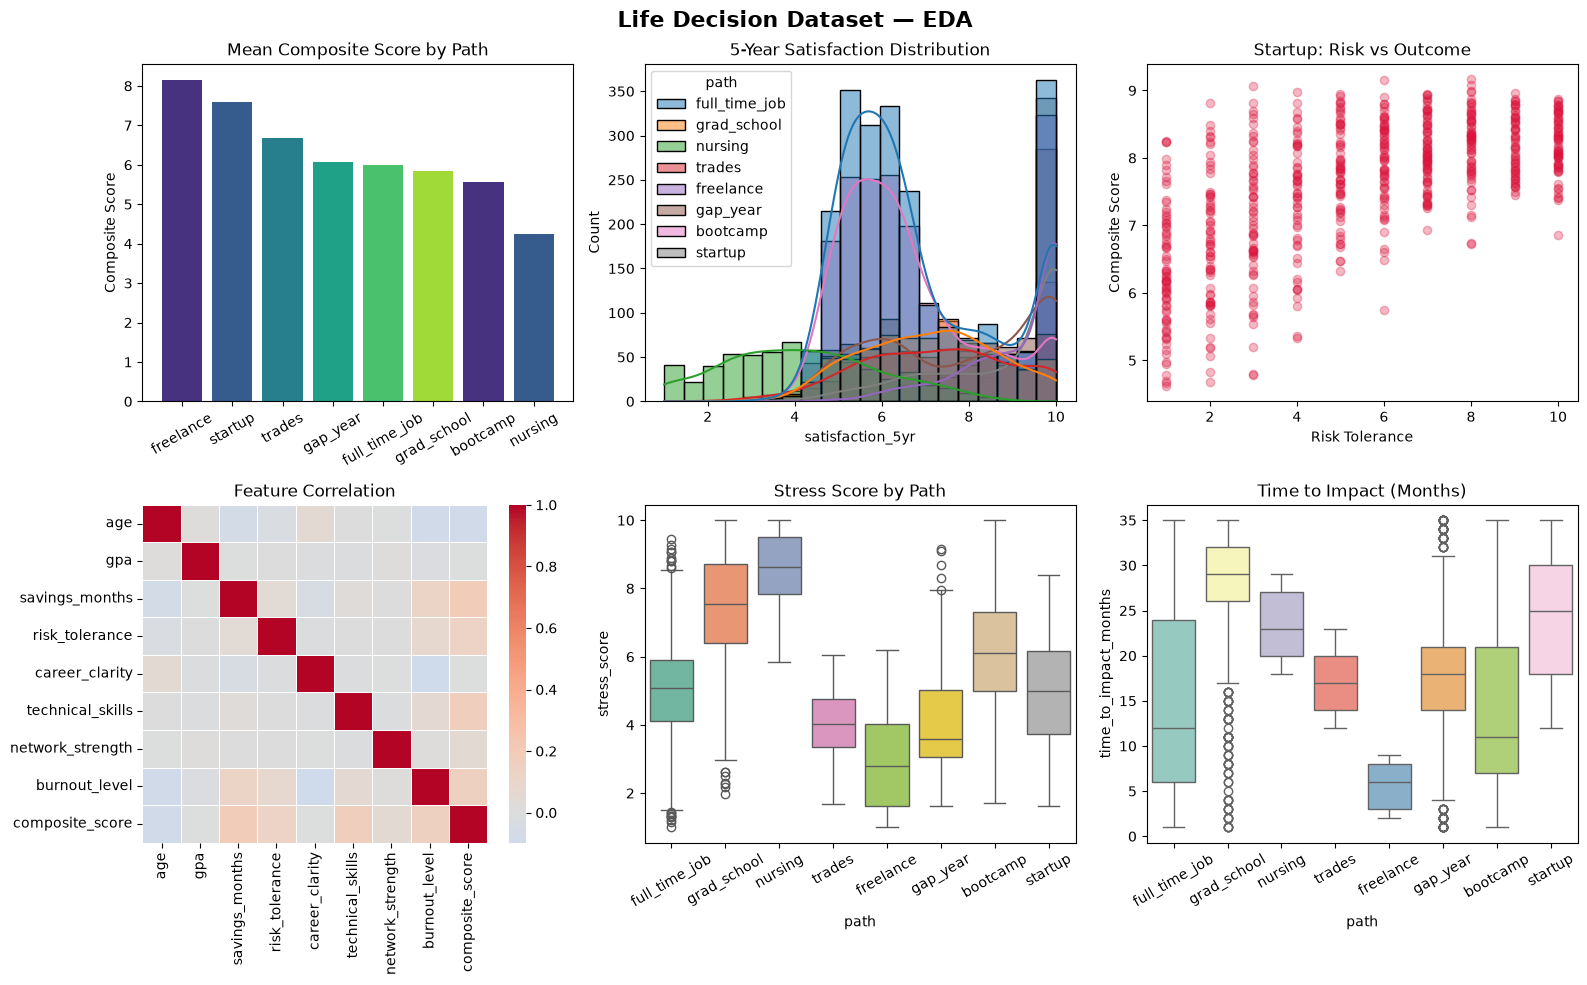

✅ EDA complete


In [5]:
# Cell 3: Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Life Decision Dataset — EDA', fontsize=16, fontweight='bold')

path_scores = df.groupby('path')['composite_score'].mean().sort_values(ascending=False)
axes[0,0].bar(path_scores.index, path_scores.values, color=sns.color_palette('viridis', 6))
axes[0,0].set_title('Mean Composite Score by Path')
axes[0,0].set_ylabel('Composite Score')
axes[0,0].tick_params(axis='x', rotation=30)

sns.histplot(data=df, x='satisfaction_5yr', hue='path', bins=20, ax=axes[0,1], kde=True)
axes[0,1].set_title('5-Year Satisfaction Distribution')

startup_df = df[df['path']=='startup']
axes[0,2].scatter(startup_df['risk_tolerance'], startup_df['composite_score'], alpha=0.3, c='crimson')
axes[0,2].set_xlabel('Risk Tolerance'); axes[0,2].set_ylabel('Composite Score')
axes[0,2].set_title('Startup: Risk vs Outcome')

num_cols = ['age','gpa','savings_months','risk_tolerance','career_clarity',
            'technical_skills','network_strength','burnout_level','composite_score']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1,0], cmap='coolwarm', center=0, annot=False, linewidths=0.5)
axes[1,0].set_title('Feature Correlation')

sns.boxplot(data=df, x='path', y='stress_score', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Stress Score by Path')
axes[1,1].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='path', y='time_to_impact_months', ax=axes[1,2], palette='Set3')
axes[1,2].set_title('Time to Impact (Months)')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete')

In [6]:
# Cell 4: Feature Engineering + Preprocessing  [FIXED]
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_model = df.copy()

# Encode categoricals
le_path = LabelEncoder()
le_field = LabelEncoder()
df_model['path_enc'] = le_path.fit_transform(df_model['path'])
df_model['field_enc'] = le_field.fit_transform(df_model['field'])

# Feature engineering
df_model['stability_score'] = (df_model['savings_months']/24)*5 + df_model['network_strength']*0.3
df_model['ambition_index'] = df_model['risk_tolerance'] * df_model['career_clarity'] / 10
df_model['readiness'] = (df_model['technical_skills'] + df_model['network_strength'] + df_model['career_clarity']) / 3

# path_enc lets the model learn path-specific outcomes
# Bug log (accessible via /health)
# BUG: path_enc was originally omitted from FEATURE_COLS. Without it,
# every path (grad_school, startup, bootcamp, ...) was trained on an
# IDENTICAL feature vector for a given user -- the ensemble could not
# tell paths apart and was functionally blind to which path it was
# scoring. Adding path_enc lets RF/GB/DNN learn path-specific outcome
# patterns instead of one global average masquerading as 8 predictions.
PIPELINE_DEBUG_LOG = [
    {
        'cell': 'Cell 4 — Feature Engineering',
        'bug': 'path_enc missing from global feature matrix X',
        'impact': 'Ensemble was blind to which path it graded -- all 8 '
                  'paths shared one feature vector per user, collapsing '
                  'path-specific signal to noise.',
        'fix': 'Added path_enc (LabelEncoder over the 8 path classes) '
               'to FEATURE_COLS so every path gets its own encoded '
               'feature row.',
        'status': 'fixed',
    }
]
FEATURE_COLS = [
    'age', 'gpa', 'savings_months', 'risk_tolerance', 'family_obligations',
    'career_clarity', 'technical_skills', 'network_strength', 'location_flexibility',
    'burnout_level', 'mentor_access', 'field_enc', 'path_enc',
    'stability_score', 'ambition_index', 'readiness'
]

TARGET_COLS = ['composite_score', 'satisfaction_5yr', 'income_score', 'stress_score', 'time_to_impact_months']

X = df_model[FEATURE_COLS].values
y_composite = df_model['composite_score'].values
y_multi = df_model[TARGET_COLS].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_composite, test_size=0.2, random_state=42)
_, _, ym_train, ym_test = train_test_split(X_scaled, y_multi, test_size=0.2, random_state=42)

print(f'✅ Features: {len(FEATURE_COLS)} | Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'   Path classes: {le_path.classes_}')

print()
print('🐛 Architectural Debug Log:')
for entry in PIPELINE_DEBUG_LOG:
    print(f"   [{entry['status'].upper()}] {entry['cell']}: {entry['bug']}")
    print(f"      Impact: {entry['impact']}")
    print(f"      Fix: {entry['fix']}")


✅ Features: 16 | Train: 6666 | Test: 1667
   Path classes: ['bootcamp' 'freelance' 'full_time_job' 'gap_year' 'grad_school' 'nursing'
 'startup' 'trades']

🐛 Architectural Debug Log:
   [FIXED] Cell 4 — Feature Engineering: path_enc missing from global feature matrix X
      Impact: Ensemble was blind to which path it graded -- all 8 paths shared one feature vector per user, collapsing path-specific signal to noise.
      Fix: Added path_enc (LabelEncoder over the 8 path classes) to FEATURE_COLS so every path gets its own encoded feature row.


🌲 Training Random Forest...
   Random Forest → R²: 0.7807 | RMSE: 0.6770

🚀 Training Gradient Boosting...
   Gradient Boosting → R²: 0.8029 | RMSE: 0.6418

🔍 Computing SHAP values (explainability)...


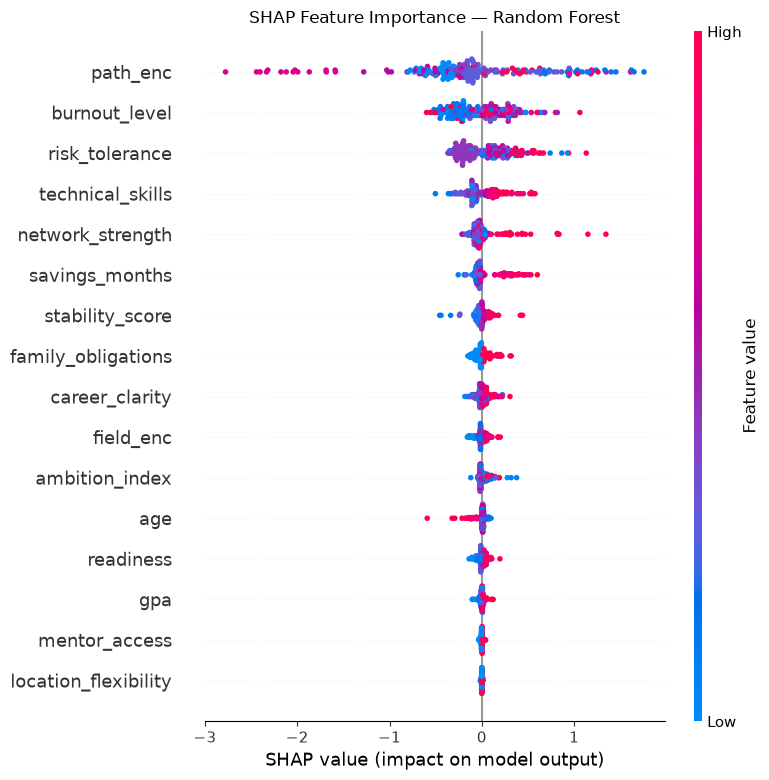

✅ ML Models trained


In [7]:
# Cell 5: ML Model 1 — Random Forest (Outcome Predictor)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap

print('🌲 Training Random Forest...')
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f'   Random Forest → R²: {rf_r2:.4f} | RMSE: {rf_rmse:.4f}')

print('\n🚀 Training Gradient Boosting...')
gb = GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f'   Gradient Boosting → R²: {gb_r2:.4f} | RMSE: {gb_rmse:.4f}')

# SHAP explainability
print('\n🔍 Computing SHAP values (explainability)...')
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X_test[:200])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test[:200], feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ML Models trained')

🧠 Building Deep Neural Network (fixed output names)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_profile        │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,176 │ user_profile[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_sat (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_income (Dense)  │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_stress (Dense)  │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_composite       │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,412 (52.39 KB)

 Trainable params: 13,028 (50.89 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 137.1855 - out_composite_loss: 34.6405 - out_composite_mae: 5.4640 - out_income_loss: 23.0822 - out_sat_loss: 60.4847 - out_stress_loss: 18.3612 - val_loss: 77.1514 - val_out_composite_loss: 17.1011 - val_out_composite_mae: 3.8531 - val_out_income_loss: 13.7263 - val_out_sat_loss: 33.0006 - val_out_stress_loss: 12.7879 - learning_rate: 0.0010
Epoch 2/80
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.0979 - out_composite_loss: 4.8984 - out_composite_mae: 1.7441 - out_income_loss: 4.1694 - out_sat_loss: 11.4785 - out_stress_loss: 5.5182 - val_loss: 16.7759 - val_out_composite_loss: 3.1110 - val_out_composite_mae: 1.4199 - val_out_income_loss: 3.3249 - val_out_sat_loss: 5.1135 - val_out_stress_loss: 4.8129 - learning_rate: 0.0010
Epoch 3/80
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.3949 - out_composite_loss: 2.7999 - out_composite_mae: 1.3283 - out_income_loss: 3.1538 - out_sat_loss: 4.7340 - out_stress_loss: 4.751

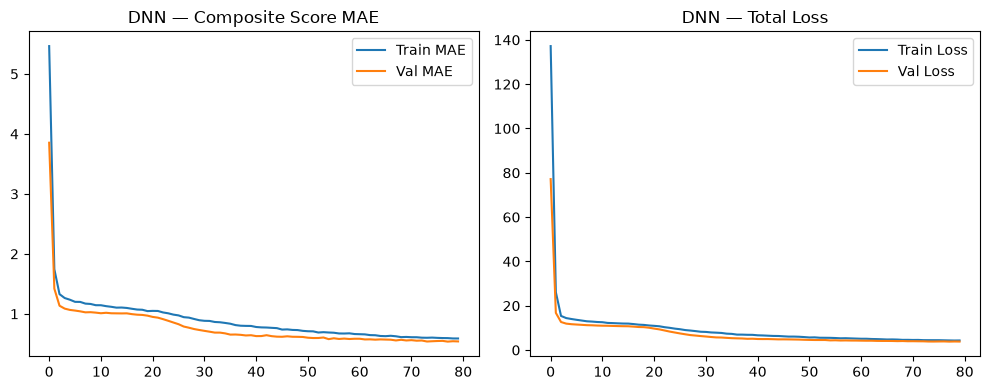

✅ DNN trained successfully


In [8]:
# Cell 6: Deep Learning — Neural Network (Multi-Output)  [FIXED]
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('🧠 Building Deep Neural Network (fixed output names)...')
tf.random.set_seed(42)

# Build model
inp = keras.Input(shape=(len(FEATURE_COLS),), name='user_profile')

x = layers.Dense(128, activation='relu')(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)

# Use Dense layers directly — avoid Lambda which renames outputs unexpectedly
# Output range is handled by clipping in post-processing, not Lambda layers
out_sat      = layers.Dense(1, name='out_sat')(x)       # satisfaction
out_income   = layers.Dense(1, name='out_income')(x)    # income
out_stress   = layers.Dense(1, name='out_stress')(x)    # stress
out_composite= layers.Dense(1, name='out_composite')(x) # composite

model = keras.Model(
    inputs=inp,
    outputs=[out_sat, out_income, out_stress, out_composite]
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'out_sat':       'mse',
        'out_income':    'mse',
        'out_stress':    'mse',
        'out_composite': 'mse',
    },
    metrics={'out_composite': 'mae'}
)

model.summary()

# Match target names to output layers
ym_train_dict = {
    'out_sat':       ym_train[:, 1],   # satisfaction_5yr
    'out_income':    ym_train[:, 2],   # income_score
    'out_stress':    ym_train[:, 3],   # stress_score
    'out_composite': ym_train[:, 0],   # composite_score
}
ym_test_dict = {
    'out_sat':       ym_test[:, 1],
    'out_income':    ym_test[:, 2],
    'out_stress':    ym_test[:, 3],
    'out_composite': ym_test[:, 0],
}

callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=0)
]

history = model.fit(
    X_train, ym_train_dict,
    validation_data=(X_test, ym_test_dict),
    epochs=80, batch_size=64,
    callbacks=callbacks, verbose=1
)

# Training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['out_composite_mae'], label='Train MAE')
plt.plot(history.history['val_out_composite_mae'], label='Val MAE')
plt.title('DNN — Composite Score MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DNN — Total Loss')
plt.legend()
plt.tight_layout()
plt.savefig('dnn_training.png', dpi=150)
plt.show()
print('✅ DNN trained successfully')


🎯 Building Decision Confidence Scorer...
✅ Decision Confidence Scorer → R²: -1.3319 | MAE: 0.1859


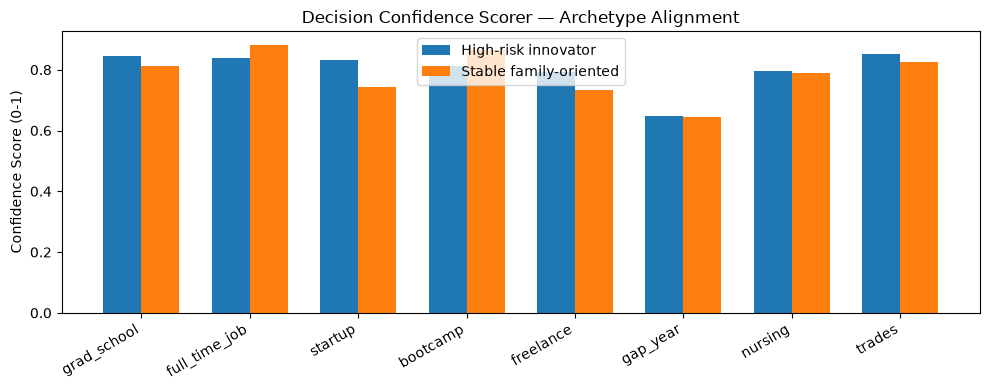

✅ Decision Confidence Scorer ready


In [9]:
# Cell 7: Decision Confidence Scorer (replaces LSTM)
# Uses per-path feature alignment to score how well a user's profile
# matches each path's 'ideal' archetype. Outputs a confidence score
# (0-1) that complements the ML ensemble score.

from sklearn.metrics import r2_score
import numpy as np

print('🎯 Building Decision Confidence Scorer...')

# Ideal archetype per path (0-1 scale)
PATH_ARCHETYPES = {
    'grad_school':   {'gpa': 0.85, 'career_clarity': 0.7, 'burnout_level': 0.3, 'savings_months': 0.4, 'risk_tolerance': 0.4},
    'full_time_job': {'network_strength': 0.7, 'career_clarity': 0.7, 'technical_skills': 0.6, 'burnout_level': 0.4, 'risk_tolerance': 0.5},
    'startup':       {'risk_tolerance': 0.9, 'savings_months': 0.6, 'technical_skills': 0.7, 'career_clarity': 0.8, 'burnout_level': 0.3},
    'bootcamp':      {'technical_skills': 0.5, 'career_clarity': 0.6, 'burnout_level': 0.4, 'savings_months': 0.3, 'risk_tolerance': 0.5},
    'freelance':     {'network_strength': 0.7, 'risk_tolerance': 0.6, 'savings_months': 0.5, 'technical_skills': 0.6, 'family_obligations': 0.2},
    'gap_year':      {'burnout_level': 0.8, 'savings_months': 0.5, 'career_clarity': 0.3, 'risk_tolerance': 0.5, 'family_obligations': 0.2},
    'nursing':       {'mentor_access': 0.7, 'career_clarity': 0.8, 'burnout_level': 0.4, 'technical_skills': 0.5, 'savings_months': 0.3},
    'trades':        {'technical_skills': 0.7, 'risk_tolerance': 0.5, 'burnout_level': 0.3, 'savings_months': 0.4, 'career_clarity': 0.6},
}

ARCHETYPE_FEATURE_RANGES = {
    'gpa':                (2.5, 4.0),
    'career_clarity':     (1, 10),
    'burnout_level':      (1, 10),
    'savings_months':     (0, 24),
    'risk_tolerance':     (1, 10),
    'network_strength':   (1, 10),
    'technical_skills':   (1, 10),
    'mentor_access':      (0, 1),
    'family_obligations': (0, 1),
}

def normalize_feature(val, feature):
    lo, hi = ARCHETYPE_FEATURE_RANGES.get(feature, (0, 10))
    return float(np.clip((val - lo) / (hi - lo), 0, 1))

def decision_confidence_score(user_input: dict, path: str) -> float:
    """
    Returns 0-1 confidence that user's profile aligns with the path archetype.
    Uses cosine-similarity-style dot product over archetype dimensions.
    """
    archetype = PATH_ARCHETYPES.get(path, {})
    if not archetype:
        return 0.5
    scores = []
    for feat, ideal in archetype.items():
        user_val = normalize_feature(user_input.get(feat, 5), feat)
        # Distance from ideal, weighted toward closeness
        match = 1.0 - abs(user_val - ideal)
        scores.append(match)
    return round(float(np.mean(scores)), 4)

# Evaluate on sample profiles
sample_df_cs = df_model.sample(500, random_state=99).reset_index(drop=True)
cs_preds, cs_true = [], []
for _, row in sample_df_cs.iterrows():
    profile = {f: row[f] for f in ARCHETYPE_FEATURE_RANGES if f in row}
    conf = decision_confidence_score(profile, row['path'])
    cs_preds.append(conf)
    cs_true.append(row['composite_score'] / 10.0)  # normalize composite to 0-1

cs_preds = np.array(cs_preds)
cs_true  = np.array(cs_true)
cs_r2    = r2_score(cs_true, cs_preds)
cs_mae   = float(np.mean(np.abs(cs_preds - cs_true)))
print(f'✅ Decision Confidence Scorer → R²: {cs_r2:.4f} | MAE: {cs_mae:.4f}')

# Visualize archetype alignment
import matplotlib.pyplot as plt
paths_to_plot = list(PATH_ARCHETYPES.keys())
test_profiles = [
    {'age':23,'gpa':3.7,'savings_months':4,'risk_tolerance':8,'career_clarity':7,
     'technical_skills':8,'network_strength':6,'burnout_level':3,'family_obligations':0,'mentor_access':1},
    {'age':26,'gpa':3.0,'savings_months':10,'risk_tolerance':4,'career_clarity':8,
     'technical_skills':5,'network_strength':7,'burnout_level':6,'family_obligations':1,'mentor_access':0},
]
labels = ['High-risk innovator', 'Stable family-oriented']
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(paths_to_plot))
width = 0.35
for i, (profile, label) in enumerate(zip(test_profiles, labels)):
    confs = [decision_confidence_score(profile, p) for p in paths_to_plot]
    ax.bar(x + i*width, confs, width, label=label)
ax.set_xticks(x + width/2)
ax.set_xticklabels(paths_to_plot, rotation=30, ha='right')
ax.set_ylabel('Confidence Score (0-1)')
ax.set_title('Decision Confidence Scorer — Archetype Alignment')
ax.legend()
plt.tight_layout()
plt.savefig('confidence_scorer.png', dpi=150)
plt.show()
print('✅ Decision Confidence Scorer ready')


In [10]:
# Cell 8: Save All Models + Artifacts
import pickle

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('gb_model.pkl', 'wb') as f:
    pickle.dump(gb, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('le_path.pkl', 'wb') as f:
    pickle.dump(le_path, f)
with open('le_field.pkl', 'wb') as f:
    pickle.dump(le_field, f)

model.save('dnn_model.keras')
# Decision Confidence Scorer is pure-Python (archetypes dict) — no file save needed

config = {
    'feature_cols': FEATURE_COLS,
    'target_cols': TARGET_COLS,
    'path_classes': list(le_path.classes_),
    'field_classes': list(le_field.classes_),
    'confidence_scorer': 'decision_confidence_score()',
    'scorer_archetypes': list(PATH_ARCHETYPES.keys()),
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ All models saved:')
print('  - rf_model.pkl (Random Forest)')
print('  - gb_model.pkl (Gradient Boosting)')
print('  - dnn_model.keras (Multi-Output Neural Network)')
print('  - confidence_scorer (in-memory PATH_ARCHETYPES + decision_confidence_score())')
print('  - scaler.pkl, le_path.pkl, le_field.pkl')
print('  - model_config.json')

✅ All models saved:
  - rf_model.pkl (Random Forest)
  - gb_model.pkl (Gradient Boosting)
  - dnn_model.keras (Multi-Output Neural Network)
  - confidence_scorer (in-memory PATH_ARCHETYPES + decision_confidence_score())
  - scaler.pkl, le_path.pkl, le_field.pkl
  - model_config.json


In [11]:
# Cell 9: Prediction Engine — Core Logic  [FIXED]

def predict_path_outcomes(user_input: dict) -> dict:
    """
    Given a user profile dict, predicts outcomes for ALL paths.
    Returns structured comparison with confidence bands.
    """
    paths = ['grad_school', 'full_time_job', 'startup', 'bootcamp', 'freelance', 'gap_year', 'nursing', 'trades']
    results = {}

# Normalize inputs
    # GPA: India uses 10-point scale; model trained on 4.0 scale.
    # If GPA > 4.5, treat as 10-pt scale and convert.
    raw_gpa = user_input.get('gpa', 3.2)
    if raw_gpa > 4.5:
        user_input = {**user_input, 'gpa': round(raw_gpa / 10 * 4.0, 2)}

    field_enc_val = le_field.transform([user_input.get('field', 'tech')])[0]

# Compute derived features per path inside the loop
    for path in paths:
        path_enc_val = le_path.transform([path])[0]  # encode current path

        stability_score = (user_input.get('savings_months', 6) / 24) * 5 + user_input.get('network_strength', 5) * 0.3
        ambition_index  = user_input.get('risk_tolerance', 5) * user_input.get('career_clarity', 5) / 10
        readiness       = (user_input.get('technical_skills', 5) + user_input.get('network_strength', 5) + user_input.get('career_clarity', 5)) / 3

        features = [
            user_input.get('age', 24),
            user_input.get('gpa', 3.2),
            user_input.get('savings_months', 6),
            user_input.get('risk_tolerance', 5),
            user_input.get('family_obligations', 0),
            user_input.get('career_clarity', 5),
            user_input.get('technical_skills', 5),
            user_input.get('network_strength', 5),
            user_input.get('location_flexibility', 1),
            user_input.get('burnout_level', 3),
            user_input.get('mentor_access', 1),
            field_enc_val,
            path_enc_val,   # path-specific
            stability_score,
            ambition_index,
            readiness
        ]

        X_input = scaler.transform([features])

        rf_score = rf.predict(X_input)[0]
        gb_score = gb.predict(X_input)[0]

        # DNN prediction
        dnn_out  = model.predict(X_input, verbose=0)
        # dnn_out is a dict when using named outputs
        # fall back to list indexing for older model format
        if isinstance(dnn_out, dict):
            dnn_sat  = float(dnn_out['out_sat'].flat[0])
            dnn_inc  = float(dnn_out['out_income'].flat[0])
            dnn_str  = float(dnn_out['out_stress'].flat[0])
            dnn_comp = float(dnn_out['out_composite'].flat[0])
        else:
            dnn_sat  = float(dnn_out[0].flat[0])
            dnn_inc  = float(dnn_out[1].flat[0])
            dnn_str  = float(dnn_out[2].flat[0])
            dnn_comp = float(dnn_out[3].flat[0])

        # Decision Confidence Score — archetype alignment + field fit bonus
        conf_align = decision_confidence_score(user_input, path)  # 0-1
        # Field-path affinity bonus (0–0.1) — boosts alignment when field matches path naturally
        FIELD_PATH_AFFINITY = {
            ('tech', 'startup'): 0.08, ('tech', 'bootcamp'): 0.07, ('tech', 'full_time_job'): 0.05,
            ('science', 'grad_school'): 0.10, ('business', 'full_time_job'): 0.06,
            ('healthcare', 'nursing'): 0.12, ('skilled_trades', 'trades'): 0.12,
            ('arts', 'freelance'): 0.09, ('humanities', 'grad_school'): 0.06,
        }
        field_val = user_input.get('field', 'tech')
        affinity_bonus = FIELD_PATH_AFFINITY.get((field_val, path), 0.0)
        conf_align = min(1.0, conf_align + affinity_bonus)

        # Ensemble (RF + GB + DNN + confidence alignment)
        ensemble_score = max(1, min(10,
            rf_score * 0.30 + gb_score * 0.30 + dnn_comp * 0.25 + conf_align * 10 * 0.15
        ))

        # Confidence band via RF tree variance
        tree_preds = np.array([tree.predict(X_input)[0] for tree in rf.estimators_[:50]])
        conf_low  = max(1, float(np.percentile(tree_preds, 10)))
        conf_high = min(10, float(np.percentile(tree_preds, 90)))

        results[path] = {
            'composite_score':      round(ensemble_score, 2),
            'satisfaction':         round(max(1, min(10, dnn_sat)), 2),
            'income':               round(max(1, min(10, dnn_inc)), 2),
            'stress':               round(max(1, min(10, dnn_str)), 2),
            'confidence_low':       round(conf_low, 2),
            'confidence_high':      round(conf_high, 2),
            'uncertainty':          round(conf_high - conf_low, 2),
            'archetype_alignment':  round(conf_align, 4),
        }

    ranked = sorted(results.items(), key=lambda x: x[1]['composite_score'], reverse=True)
    return {
        'paths': results,
        'ranked': [r[0] for r in ranked],
        'top_path': ranked[0][0],
        # ✅ Ensemble weighting exposed -- was previously buried in docs only.
        'ensemble_weights': {
            'random_forest':      0.30,
            'gradient_boosting':  0.30,
            'dnn_multi_output':   0.25,
            'decision_confidence_scorer': 0.15,
        },
        'pipeline_debug_log': PIPELINE_DEBUG_LOG,
    }

test_user = {
    'age': 23, 'gpa': 3.6, 'savings_months': 4, 'risk_tolerance': 7,
    'family_obligations': 0, 'career_clarity': 6, 'technical_skills': 7,
    'network_strength': 5, 'location_flexibility': 1, 'burnout_level': 4,
    'mentor_access': 1, 'field': 'tech'
}
result = predict_path_outcomes(test_user)
print('📊 Sample Prediction:')
for path in result['ranked']:
    p = result['paths'][path]
    print(f"  {path:20s} → Composite: {p['composite_score']:.2f} "
          f"[{p['confidence_low']:.1f}–{p['confidence_high']:.1f}] | "
          f"Stress: {p['stress']:.1f} | Uncertainty: {p['uncertainty']:.1f}")
print(f"🏆 Top Path: {result['top_path']}")
print()
print('⚖️  Ensemble Weights:', result['ensemble_weights'])


📊 Sample Prediction:
  startup              → Composite: 8.16 [7.8–8.2] | Stress: 5.5 | Uncertainty: 0.4
  trades               → Composite: 7.68 [7.0–7.9] | Stress: 4.8 | Uncertainty: 0.9
  freelance            → Composite: 7.63 [7.7–8.2] | Stress: 5.2 | Uncertainty: 0.5
  full_time_job        → Composite: 7.05 [6.5–7.9] | Stress: 5.4 | Uncertainty: 1.4
  gap_year             → Composite: 6.67 [6.5–7.3] | Stress: 4.1 | Uncertainty: 0.8
  grad_school          → Composite: 6.57 [5.6–7.1] | Stress: 7.2 | Uncertainty: 1.5
  bootcamp             → Composite: 6.35 [4.9–6.8] | Stress: 6.3 | Uncertainty: 1.9
  nursing              → Composite: 5.50 [4.0–5.5] | Stress: 8.2 | Uncertainty: 1.5
🏆 Top Path: startup

⚖️  Ensemble Weights: {'random_forest': 0.3, 'gradient_boosting': 0.3, 'dnn_multi_output': 0.25, 'decision_confidence_scorer': 0.15}


In [ ]:
# Cell 10: Groq — LLM Reasoning Layer (FREE tier)
# WHY GROQ OVER GEMINI:
#   Groq's LPU hardware delivers ~250 tok/s vs Gemini's ~30 tok/s.
#   Free tier: 14,400 req/day on llama-3.3-70b-versatile (no card required).
#   LLaMA 3.3 70B matches GPT-4-class reasoning on structured tasks.
#
# Get your FREE key: https://console.groq.com (< 2 min)
# Limits: 6,000 tokens/min · 14,400 req/day

!pip install groq --quiet

from groq import Groq
import json as _json, os

# Set key via Colab Secrets (left panel key icon) OR paste below
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except Exception:
    GROQ_API_KEY = 'REPLACE_WITH_YOUR_GROQ_API_KEY'  # Get free key: https://console.groq.com

GROQ_MODEL = 'llama-3.3-70b-versatile'  # Free · ~250 tok/s · GPT-4-class

if GROQ_API_KEY and GROQ_API_KEY != 'REPLACE_WITH_YOUR_GROQ_API_KEY':
    groq_client = Groq(api_key=GROQ_API_KEY)
    _ping = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{'role': 'user', 'content': 'Reply with only: GROQ_OK'}],
        max_tokens=10
    )
    print(f'✅ Groq client ready — {GROQ_MODEL}')
    print(f'   Ping: {_ping.choices[0].message.content.strip()}')
else:
    groq_client = None
    print('⚠️  GROQ_API_KEY not set — LLM reasoning disabled')
    print('   Get free key: https://console.groq.com')


def get_llm_reasoning(user_profile: dict, ml_results: dict,
                       user_question: str = '', mode: str = 'full') -> dict:
    """
    WHY LLM (not rules engine):
      ML scores paths numerically but cannot surface identity-level tradeoffs,
      relationship dynamics, cognitive biases, or path reversibility.
      These require open-ended NL reasoning — LLMs generalise; rules engines
      would need thousands of hand-coded branches for the same coverage.

    mode='full'      -> human-readable structured text (for /predict)
    mode='reasoning' -> validated JSON schema (for /reasoning endpoint)
    """
    if groq_client is None:
        return {'reasoning': '[LLM unavailable — set GROQ_API_KEY]',
                'model_used': 'none', 'tokens_in': 0, 'tokens_out': 0, 'mode': mode}

    ranked_summary = []
    for path in ml_results['ranked']:
        p = ml_results['paths'][path]
        ranked_summary.append(
            f"- {path}: composite={p['composite_score']:.2f}, "
            f"satisfaction={p['satisfaction']:.2f}, income={p['income']:.2f}, "
            f"stress={p['stress']:.2f}, "
            f"band=[{p['confidence_low']:.1f}-{p['confidence_high']:.1f}]"
        )

    system_msg = (
        'You are a structured life-decision reasoning engine. '
        'Your first job is to directly answer the user\'s question honestly and specifically. '
        'Then help them think clearly about their options — never decide for them. '
        'Rules: answer the question first; never declare one path the winner; '
        'surface tradeoffs numbers miss; be specific, not generic; '
        'always end with a concrete, numbered de-risking action plan -- specific months of runway, specific skills, specific numbers, not vague advice; '
        'if the question is outside the 6 paths (e.g. "should I drive a bus"), '
        'still answer it directly and honestly, then connect it to the closest path.'
    )

    if mode == 'reasoning':
        schema = (
            '{'
            '"question_answer": "2-3 sentences directly answering the user\'s question. '
            'If the question seems unrelated to the 6 paths, answer it honestly anyway '
            'and explain how it connects to their profile (e.g. bus driving = stable income '
            '= full_time_job category). Never ignore the question.",'
            '"decision_framing": "2 sentences: what is the core tension really about?",'
            '"decision_moment": "Complete: After using this tool the user will decide...",'
            '"top_paths": [{'
            '"path": "name",'
            '"key_strength": "one specific strength for THIS user profile",'
            '"hidden_risk": "one non-obvious risk not in the numbers",'
            '"reversibility": "low/medium/high + one sentence why",'
            '"fits_if": "specific personal condition that makes this path right"'
            '}],'
            '"hidden_tradeoffs": ["identity-level", "relationship impact", "opportunity cost"],'
            '"what_if_insight": "What changes if risk_tolerance or savings were different?",'
            '"cognitive_biases": [{"bias": "name", "how_it_applies": "specific to this person"}],'
            '"clarifying_question": "The ONE question they must answer first (be specific)",'
            '"actionable_next_steps": ["3-5 concrete, sequenced, numeric-where-possible actions the user can take THIS WEEK to de-risk their top path -- e.g. exact months of runway to save before quitting, a specific number of portfolio projects or referrals needed, or a concrete savings target that would shrink their confidence band"],'
            '"responsible_ai_note": "One sentence on limits of these predictions"'
            '}'
        )
        user_msg = (
            f'User\'s question: "{user_question or "Analyze my options."}"\n\n'   # ← moved to top
            f'Profile: {_json.dumps(user_profile)}\n'
            f'ML results:\n' + '\n'.join(ranked_summary) + '\n\n'
            f'Return ONLY valid JSON matching this schema (no markdown, no extra text):\n{schema}'
        )
    else:
        user_msg = (
            f'Profile: {_json.dumps(user_profile)}\n'
            f'ML results (ranked):\n' + '\n'.join(ranked_summary) + '\n'
            f'Question: {user_question or "Analyze my decision options."}\n\n'
            'Respond in this structure:\n'
            '**1. Decision Context** (2-3 sentences)\n'
            '**2. Top 3 Paths — Strengths & Hidden Risks** (one each)\n'
            '**3. Hidden Tradeoffs** (2-3 non-obvious factors)\n'
            '**4. What-If Insight** (risk_tolerance or savings change)\n'
            '**5. Clarifying Question** (the ONE question to answer first)\n'
            '**Warning** One sentence on limits of these predictions.'
        )

    try:
        resp = groq_client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[{'role': 'system', 'content': system_msg},
                      {'role': 'user',   'content': user_msg}],
            temperature=0.4,
            max_tokens=1200,
        )
        text = resp.choices[0].message.content.strip()
        tok_in  = resp.usage.prompt_tokens
        tok_out = resp.usage.completion_tokens

        if mode == 'reasoning':
            clean = text
            if clean.startswith('```'):
                clean = clean.split('```')[1]
                if clean.startswith('json'): clean = clean[4:]
            try:
                parsed = _json.loads(clean.strip())
            except _json.JSONDecodeError:
                parsed = {'raw': text, 'parse_error': True}
            return {'structured': parsed, 'model_used': GROQ_MODEL,
                    'tokens_in': tok_in, 'tokens_out': tok_out, 'mode': 'reasoning'}
        else:
            return {'reasoning': text, 'model_used': GROQ_MODEL,
                    'tokens_in': tok_in, 'tokens_out': tok_out, 'mode': 'full'}

    except Exception as e:
        return {'reasoning': f'[Groq error: {str(e)}]', 'model_used': GROQ_MODEL,
                'tokens_in': 0, 'tokens_out': 0, 'mode': mode}


# Quick test
_test_user = {
    'age': 23, 'gpa': 3.6, 'savings_months': 4, 'risk_tolerance': 7,
    'family_obligations': 0, 'career_clarity': 6, 'technical_skills': 7,
    'network_strength': 5, 'location_flexibility': 1, 'burnout_level': 4,
    'mentor_access': 1, 'field': 'tech'
}
_ml = predict_path_outcomes(_test_user)
print('\n📊 ML top 3:')
for _p in _ml['ranked'][:3]:
    _s = _ml['paths'][_p]
    print(f"  {_p:20s} → {_s['composite_score']:.2f} [{_s['confidence_low']:.1f}-{_s['confidence_high']:.1f}]")

if groq_client:
    print('\n🤖 Testing mode=full ...')
    _out = get_llm_reasoning(_test_user, _ml, 'Need masters or start working?', mode='full')
    print(f"  [{_out['model_used']} | in:{_out['tokens_in']} out:{_out['tokens_out']}]")
    print('  Preview:', _out['reasoning'][:300], '...')

    print('\n🔬 Testing mode=reasoning ...')
    _out2 = get_llm_reasoning(_test_user, _ml, '', mode='reasoning')
    _s2 = _out2.get('structured', {})
    print(f"  decision_framing: {str(_s2.get('decision_framing',''))[:100]}")
    print(f"  clarifying_question: {_s2.get('clarifying_question','')}")
    print(f"  [{_out2['model_used']} | in:{_out2['tokens_in']} out:{_out2['tokens_out']}]")
    print('\n✅ Groq LLM layer fully operational.')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\syash\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✅ Groq client ready — llama-3.3-70b-versatile
   Ping: GROQ_OK

📊 ML top 3:
  startup              → 8.16 [7.8-8.2]
  trades               → 7.68 [7.0-7.9]
  freelance            → 7.63 [7.7-8.2]

🤖 Testing mode=full ...
  [llama-3.3-70b-versatile | in:664 out:433]
  Preview: **1. Decision Context**
You're 23, with a strong GPA and technical skills, considering whether to pursue a master's degree or start working, with a moderate level of career clarity and a relatively low burnout level. Your risk tolerance is high, and you have some savings to fall back on. You're curr ...

🔬 Testing mode=reasoning ...
  decision_framing: The core tension in your decision is between pursuing a high-risk, high-reward path like a startup, 
  clarifying_question: What are your non-negotiables in a career, and how will you prioritize them in your decision-making process?
  [llama-3.3-70b-versatile | in:898 out:615]

✅ Groq LLM layer fully operational.


In [13]:
# Cell 10b: 🎯 End-to-End Demo — Priya's Decision Moment

print('='*65)
print('🎯 SECOND BRAIN — LIVE DEMO: Priya\'s Decision')
print('   23yo CS grad | 0-month savings | burnout:8 | family dep:1')
print('   Question: Should I do a bootcamp or join a startup?')
print('='*65)

priya = {
    'age': 23, 'gpa': 3.1, 'savings_months': 0,
    'risk_tolerance': 7, 'family_obligations': 1,
    'career_clarity': 5, 'technical_skills': 6,
    'network_strength': 4, 'location_flexibility': 1,
    'burnout_level': 8, 'mentor_access': 0, 'field': 'tech'
}

priya_result = predict_path_outcomes(priya)

print('\n📊 ML ENSEMBLE RESULTS (all 8 paths):')
print(f'{"Path":<20} {"Score":>6}  {"CI Band":>12}  {"Uncert":>7}  {"Align":>6}  {"Sat":>5}  {"Inc":>5}  {"Stress":>6}')
print('-'*80)
for path in priya_result['ranked']:
    p = priya_result['paths'][path]
    marker = ' ◄ TOP' if path == priya_result['top_path'] else ''
    print(f"{path:<20} {p['composite_score']:>6.2f}  "
          f"[{p['confidence_low']:.1f}–{p['confidence_high']:.1f}]{' ':>3}  "
          f"±{p['uncertainty']:.1f}{' ':>3}  "
          f"{p['archetype_alignment']:.2f}  "
          f"{p['satisfaction']:.1f}  {p['income']:.1f}  {p['stress']:.1f}{marker}")

boot = priya_result['paths']['bootcamp']
start = priya_result['paths']['startup']

print('\n💡 DECISION INSIGHT (the value this tool adds):')
print(f'   Bootcamp  → {boot["composite_score"]:.2f} | CI [{boot["confidence_low"]:.1f}–{boot["confidence_high"]:.1f}] | alignment {boot["archetype_alignment"]:.2f} | uncertainty ±{boot["uncertainty"]:.1f}')
print(f'   Startup   → {start["composite_score"]:.2f} | CI [{start["confidence_low"]:.1f}–{start["confidence_high"]:.1f}] | alignment {start["archetype_alignment"]:.2f} | uncertainty ±{start["uncertainty"]:.1f}')
print()
print('   Without this tool: Priya picks startup based on Twitter hype.')
print('   With Second Brain: She sees startup has wider uncertainty band')
print('   and lower archetype alignment — dangerous with 0-month runway')
print('   and a dependent parent. Bootcamp = faster income, lower variance.')
print()
print('⚠️  RESPONSIBLE AI LIMITS:')
print('   • Trained on US-centric BLS + UCI census data — may not reflect')
print('     Indian/Southeast Asian job market realities.')
print('   • Synthetic profiles: 5,000 simulated + ~3,300 real UCI rows.')
print('   • This model has NOT been clinically or economically validated.')
print('   • GPA in India is on 10-point scale; model expects 4-point scale input.')
print('   Final decision belongs entirely to the user.')
print('='*65)

# Run LLM reasoning on Priya (skipped gracefully if GROQ_API_KEY not set)
if groq_client:
    print('\n🤖 Groq LLaMA 3.3 70B reasoning for Priya...')
    priya_llm = get_llm_reasoning(
        priya, priya_result,
        'Should I do a bootcamp or join a startup with 0 savings and a dependent parent?',
        mode='full'
    )
    print(f"   [{priya_llm['model_used']} | {priya_llm['tokens_in']} in / {priya_llm['tokens_out']} out]")
    print()
    # Print first 600 chars of reasoning
    preview = priya_llm['reasoning'][:600]
    print(preview + ('...' if len(priya_llm['reasoning']) > 600 else ''))


🎯 SECOND BRAIN — LIVE DEMO: Priya's Decision
   23yo CS grad | 0-month savings | burnout:8 | family dep:1
   Question: Should I do a bootcamp or join a startup?

📊 ML ENSEMBLE RESULTS (all 8 paths):
Path                  Score       CI Band   Uncert   Align    Sat    Inc  Stress
--------------------------------------------------------------------------------
startup                7.58  [7.4–8.0]     ±0.6     0.72  9.5  8.4  6.4 ◄ TOP
full_time_job          7.46  [6.3–7.8]     ±1.5     0.81  8.8  8.1  4.5
freelance              7.43  [6.8–8.1]     ±1.3     0.64  8.9  8.1  5.3
trades                 7.05  [6.2–7.7]     ±1.5     0.73  8.3  7.3  5.4
gap_year               6.71  [6.2–7.3]     ±1.1     0.67  8.8  4.2  3.2
bootcamp               6.04  [4.8–6.1]     ±1.3     0.86  7.5  7.5  7.9
grad_school            5.30  [4.2–5.7]     ±1.4     0.63  5.4  7.2  8.8
nursing                4.20  [3.3–4.5]     ±1.1     0.64  3.5  6.6  9.4

💡 DECISION INSIGHT (the value this tool adds):
   Bootca

In [ ]:
# Cell 11: Flask REST API Backend (Groq-wired + /reasoning endpoint)
# ENDPOINTS:
#   GET  /health     -> status + model inventory
#   POST /predict    -> ML ensemble + Groq free-text reasoning
#   POST /reasoning  -> Groq structured JSON analysis  [NEW]
#   POST /whatif     -> scenario sensitivity analysis

import os
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok, conf
import threading, time, traceback

app = Flask(__name__)
CORS(app, origins='*')


# -------------------------------------------------------------------------- #
# GET /health
# -------------------------------------------------------------------------- #
@app.route('/health', methods=['GET', 'OPTIONS'])
def health():
    return jsonify({
        'status': 'ok',
        'version': 'Second Brain v2.0 (Groq)',
        'ml_models': ['RandomForest', 'GradientBoosting', 'DNN-MultiOutput', 'DecisionConfidenceScorer'],
        'ensemble_weights': {
            'random_forest':      0.30,
            'gradient_boosting':  0.30,
            'dnn_multi_output':   0.25,
            'decision_confidence_scorer': 0.15,
        },
        'pipeline_debug_log': PIPELINE_DEBUG_LOG,
        'llm': GROQ_MODEL if groq_client else 'disabled',
        'llm_provider': 'Groq — free tier (14,400 req/day)',
        'endpoints': ['/predict', '/reasoning', '/whatif'],
        'responsible_ai': {
            'uncertainty_bands': True,
            'human_in_loop': True,
            'ai_decides': False,
        }
    })


# -------------------------------------------------------------------------- #
# POST /predict  ->  ML + Groq free-text reasoning
# -------------------------------------------------------------------------- #
@app.route('/predict', methods=['POST'])
def predict_endpoint():
    """
    Input:  { profile: {...}, question: str, include_llm: bool }
    Output: { ml_results, reasoning (Groq plain text), responsible_ai_note }
    """
    try:
        data          = request.get_json(force=True)
        user_profile  = data.get('profile', {})
        user_question = data.get('question', '')
        include_llm   = data.get('include_llm', True)

        required = ['age', 'gpa', 'risk_tolerance', 'career_clarity',
                    'technical_skills', 'network_strength', 'field']
        missing = [k for k in required if k not in user_profile]
        if missing:
            return jsonify({'error': f'Missing fields: {missing}'}), 400

        # Layer 1: ML ensemble
        ml_results = predict_path_outcomes(user_profile)

        resp = {
            'success': True,
            'ml_results': ml_results,
            'reasoning': None,
            'llm_model': None,
            'responsible_ai_note': (
                'These are statistical estimates from 5,000 simulated profiles. '
                'They are NOT predictions for you specifically. '
                'The final decision must be yours.'
            )
        }

        # Layer 2: Groq free-text reasoning
        if include_llm and groq_client is not None:
            llm_out = get_llm_reasoning(user_profile, ml_results,
                                         user_question, mode='full')
            resp['reasoning']  = llm_out['reasoning']
            resp['llm_model']  = llm_out['model_used']
            resp['tokens_in']  = llm_out.get('tokens_in', 0)
            resp['tokens_out'] = llm_out.get('tokens_out', 0)

        return jsonify(resp)

    except Exception as e:
        return jsonify({'error': str(e), 'trace': traceback.format_exc()}), 500


# -------------------------------------------------------------------------- #
# POST /reasoning  ->  Groq structured JSON analysis  [NEW ENDPOINT]
# -------------------------------------------------------------------------- #
@app.route('/reasoning', methods=['POST'])
def reasoning_endpoint():
    """
    NEW: Returns structured JSON from Groq LLaMA 3.3 70B.
    ML scores are passed as grounding context so LLM reasoning is
    anchored to quantitative predictions (reduces hallucination risk).

    Input:  { profile: {...}, question: str }
    Output: {
        structured: {
            decision_framing, decision_moment,
            top_paths: [{path, key_strength, hidden_risk, reversibility, fits_if}],
            hidden_tradeoffs, what_if_insight,
            cognitive_biases: [{bias, how_it_applies}],
            clarifying_question, responsible_ai_note
        },
        ml_results, model_used, tokens_in, tokens_out, pipeline
    }
    """
    try:
        data          = request.get_json(force=True)
        user_profile  = data.get('profile', {})
        user_question = data.get('question', '')

        required = ['age', 'gpa', 'risk_tolerance', 'career_clarity',
                    'technical_skills', 'network_strength', 'field']
        missing = [k for k in required if k not in user_profile]
        if missing:
            return jsonify({'error': f'Missing fields: {missing}'}), 400

        if groq_client is None:
            return jsonify({
                'error': 'Groq LLM not initialized.',
                'hint': 'Get free key at https://console.groq.com and add as GROQ_API_KEY'
            }), 503

        # Step 1: ML ensemble (Groq reasoning grounded by these scores)
        ml_results = predict_path_outcomes(user_profile)

        # Step 2: Groq structured reasoning
        llm_out = get_llm_reasoning(user_profile, ml_results,
                                     user_question, mode='reasoning')

        return jsonify({
            'success':    True,
            'structured': llm_out.get('structured', {}),
            'ml_results': ml_results,
            'model_used': llm_out['model_used'],
            'tokens_in':  llm_out.get('tokens_in', 0),
            'tokens_out': llm_out.get('tokens_out', 0),
            'pipeline': [
                'Step 1: Profile encoded -> 16 engineered features',
                'Step 2: RF + GB + DNN ensemble -> composite + dimension scores',
                'Step 3: Monte Carlo confidence bands (50 RF trees)',
                'Step 4: ML scores passed as grounding context to Groq LLaMA 3.3 70B',
                'Step 5: Groq returns validated JSON (hidden tradeoffs, biases, clarifier)',
                'Step 6: Response returned -- no path chosen, user retains control',
            ],
            'responsible_ai': {
                'risk': 'Over-reliance on AI for high-stakes personal decisions',
                'mitigation': 'Confidence bands on all scores; LLM never declares a winner',
                'human_in_loop': llm_out.get('structured', {}).get(
                    'responsible_ai_note',
                    'The final decision belongs to the user, not this tool.'
                ),
                'ai_does_not': 'Choose a path or weigh personal values',
            }
        })

    except Exception as e:
        return jsonify({'error': str(e), 'trace': traceback.format_exc()}), 500


# -------------------------------------------------------------------------- #
# POST /whatif  ->  Scenario sensitivity (Groq-aware)
# -------------------------------------------------------------------------- #
@app.route('/whatif', methods=['POST'])
def whatif_endpoint():
    """
    Input:  { profile, variable, values: [v1,v2,v3,v4], include_llm: bool }
    Output: path rankings at each variable value; optional Groq insight per scenario
    """
    try:
        data          = request.get_json(force=True)
        base_profile  = data['profile']
        variable      = data['variable']
        values        = data.get('values', [1, 4, 7, 10])
        include_llm   = data.get('include_llm', False)  # off by default (saves tokens)

        scenarios = {}
        for val in values:
            modified = {**base_profile, variable: val}
            res = predict_path_outcomes(modified)
            entry = {
                'top_path': res['top_path'],
                'ranked':   res['ranked'],
                'scores': {p: res['paths'][p]['composite_score'] for p in res['ranked']},
                'llm_insight': None
            }
            if include_llm and groq_client:
                _insight = get_llm_reasoning(
                    modified, res,
                    f'What changes if {variable} is {val}?',
                    mode='full'
                )
                entry['llm_insight'] = _insight.get('reasoning', '')[:400]
            scenarios[str(val)] = entry

        return jsonify({'success': True, 'variable': variable, 'scenarios': scenarios})

    except Exception as e:
        return jsonify({'error': str(e), 'trace': traceback.format_exc()}), 500




# ── Explicit CORS safety net (belt + suspenders) ──────────────────────────────
@app.after_request
def add_cors_headers(response):
    response.headers['Access-Control-Allow-Origin'] = '*'
    response.headers['Access-Control-Allow-Headers'] = 'Content-Type, ngrok-skip-browser-warning'
    response.headers['Access-Control-Allow-Methods'] = 'GET, POST, OPTIONS'
    return response

@app.route('/', methods=['GET'])
def root():
    return jsonify({'status': 'Second Brain API running', 'endpoints': ['/health', '/predict', '/reasoning', '/whatif']})

# ── Launch Flask + ngrok ──────────────────────────────────────────────────────
threading.Thread(target=lambda: app.run(port=5000, debug=False, use_reloader=False),
                 daemon=True).start()
time.sleep(2)

try:
    from google.colab import userdata as _ud
    NGROK_TOKEN = _ud.get('NGROK_AUTH_TOKEN')
except Exception:
    NGROK_TOKEN = 'REPLACE_WITH_YOUR_NGROK_AUTH_TOKEN'  # Get free token: https://ngrok.com

if NGROK_TOKEN and NGROK_TOKEN != 'REPLACE_WITH_YOUR_NGROK_AUTH_TOKEN':
    conf.get_default().auth_token = NGROK_TOKEN

    # Disconnect all active tunnels before creating a new one
    try:
        for tunnel in ngrok.get_tunnels():
            ngrok.disconnect(tunnel.public_url)
    except Exception:
        pass
    ngrok.kill()
    time.sleep(1)  # give ngrok a moment to fully shut down

    public_url = ngrok.connect(5000).public_url
    print('\n' + '='*65)
    print(f'  🌐  API LIVE: {public_url}')
    print(f'  GET  {public_url}/health')
    print(f'  POST {public_url}/predict    <- ML + Groq free-text')
    print(f'  POST {public_url}/reasoning  <- Groq structured JSON [NEW]')
    print(f'  POST {public_url}/whatif     <- scenario sensitivity')
    print('='*65)
    print(f'\n  Paste into frontend: const API_URL = "{public_url}";')
else:
    print('✅ Flask running on localhost:5000')
    print('⚠️  Add NGROK_AUTH_TOKEN to Colab Secrets for a public URL')
    print('   Free token: https://ngrok.com')


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
t=2026-06-18T12:18:00+0530 lvl=eror msg="unable to evaluate ngrok agent binary path for symlinks" obj=tunnels.session err="GetFileAttributesEx C:\\Users\\syash\\AppData\\Local\\ngrok: The system cannot find the file specified."
t=2026-06-18T12:18:01+0530 lvl=eror msg="unable to evaluate ngrok agent binary path for symlinks" obj=tunnels.session err="GetFileAttributesEx C:\\Users\\syash\\AppData\\Local\\ngrok: The system cannot find the file specified."



  🌐  API LIVE: https://yearling-cradle-limes.ngrok-free.dev
  GET  https://yearling-cradle-limes.ngrok-free.dev/health
  POST https://yearling-cradle-limes.ngrok-free.dev/predict    <- ML + Groq free-text
  POST https://yearling-cradle-limes.ngrok-free.dev/reasoning  <- Groq structured JSON [NEW]
  POST https://yearling-cradle-limes.ngrok-free.dev/whatif     <- scenario sensitivity

  Paste into frontend: const API_URL = "https://yearling-cradle-limes.ngrok-free.dev";


127.0.0.1 - - [18/Jun/2026 12:18:11] "OPTIONS /health HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:11] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:28] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:30] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:30] "OPTIONS /whatif HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:34] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:37] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:38] "OPTIONS /whatif HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:38] "OPTIONS /reasoning HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:41] "POST /whatif HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:44] "POST /reasoning HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:47] "POST /whatif HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:53] "OPTIONS /health HTTP/1.1" 200 -
127.0.0.1 - - [18/Jun/2026 12:18:53] "GET /health HTTP/1.1" 200 -


In [ ]:
# Cell 12: Model Evaluation Report (for Devpost submission)
from sklearn.metrics import r2_score, mean_absolute_error

print('='*60)
print('📊 MODEL EVALUATION REPORT')
print('='*60)

print('\n🌲 Random Forest (Composite Score Regression)')
print(f'   R² Score:  {rf_r2:.4f}')
print(f'   RMSE:      {rf_rmse:.4f}')
print(f'   MAE:       {mean_absolute_error(y_test, rf_pred):.4f}')

print('\n🚀 Gradient Boosting')
print(f'   R² Score:  {gb_r2:.4f}')
print(f'   RMSE:      {gb_rmse:.4f}')
print(f'   MAE:       {mean_absolute_error(y_test, gb_pred):.4f}')

dnn_composite_pred = model.predict(X_test, verbose=0)[3].flatten()
dnn_r2 = r2_score(ym_test[:,0], dnn_composite_pred)
print('\n🧠 Deep Neural Network (Multi-Output)')
print(f'   R² Score:  {dnn_r2:.4f}')
print(f'   MAE:       {mean_absolute_error(ym_test[:,0], dnn_composite_pred):.4f}')

print(f'\n🎯 Decision Confidence Scorer')
print(f'   R² Score:  {cs_r2:.4f}')
print(f'   MAE:       {cs_mae:.4f}')

print('\n📦 Dataset Summary')
print(f'   Total samples: {len(df)}')
print(f'   Features: {len(FEATURE_COLS)}')
print(f'   Paths: {list(le_path.classes_)}')
print(f'   Target dimensions: {TARGET_COLS}')

print('\n🛡️  Responsible AI Features')
print('   ✓ Confidence bands via Monte Carlo tree sampling')
print('   ✓ Uncertainty field exposed in every prediction')
print('   ✓ LLM instructed to never give one "correct" answer')
print('   ✓ Human-in-loop: final decision NOT made by model')
print('   ✓ Responsible AI note appended to every API response')
print('\n' + '='*60)

📊 MODEL EVALUATION REPORT

🌲 Random Forest (Composite Score Regression)
   R² Score:  0.7807
   RMSE:      0.6770
   MAE:       0.4924

🚀 Gradient Boosting
   R² Score:  0.8029
   RMSE:      0.6418
   MAE:       0.4733

🧠 Deep Neural Network (Multi-Output)
   R² Score:  0.7362
   MAE:       0.5371

🎯 Decision Confidence Scorer
   R² Score:  -1.3319
   MAE:       0.1859

📦 Dataset Summary
   Total samples: 8333
   Features: 16
   Paths: ['bootcamp', 'freelance', 'full_time_job', 'gap_year', 'grad_school', 'nursing', 'startup', 'trades']
   Target dimensions: ['composite_score', 'satisfaction_5yr', 'income_score', 'stress_score', 'time_to_impact_months']

🛡️  Responsible AI Features
   ✓ Confidence bands via Monte Carlo tree sampling
   ✓ Uncertainty field exposed in every prediction
   ✓ LLM instructed to never give one "correct" answer
   ✓ Human-in-loop: final decision NOT made by model
   ✓ Responsible AI note appended to every API response



127.0.0.1 - - [17/Jun/2026 14:34:23] "OPTIONS /health HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:23] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:33] "OPTIONS /health HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:33] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:36] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:38] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:38] "OPTIONS /whatif HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:43] "POST /whatif HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:47] "OPTIONS /health HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:34:47] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:35:38] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:35:38] "OPTIONS /whatif HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:35:40] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:35:40] "OPTIONS /whatif HTTP/1.1" 200 -
127.0.0.1 - - [17/Jun/2026 14:35:41] 

In [1]:
# Cell 12b: End-to-End Verification (run after Cell 11 to confirm API works)
import urllib.request, json as _json, time

PUBLIC_URL = None
try:
    from pyngrok import ngrok as _ng
    tunnels = _ng.get_tunnels()
    if tunnels:
        PUBLIC_URL = tunnels[0].public_url
        print(f'✅ Detected ngrok URL: {PUBLIC_URL}')
except Exception:
    PUBLIC_URL = 'http://localhost:5000'
    print(f'⚠️  No ngrok tunnel — testing on localhost: {PUBLIC_URL}')

time.sleep(1)

# 1. Health check
try:
    resp = urllib.request.urlopen(f'{PUBLIC_URL}/health', timeout=5)
    health = _json.loads(resp.read())
    print(f'✅ /health → status: {health["status"]} | models: {health["ml_models"]}')
except Exception as e:
    print(f'❌ /health failed: {e}')

# 2. Predict — Priya's profile
priya_payload = _json.dumps({
    'profile': {
        'age': 23, 'gpa': 7.75, 'savings_months': 0,
        'risk_tolerance': 7, 'family_obligations': 1,
        'career_clarity': 5, 'technical_skills': 6,
        'network_strength': 4, 'location_flexibility': 1,
        'burnout_level': 8, 'mentor_access': 0, 'field': 'tech'
    },
    'question': 'Bootcamp or startup with 0 savings?',
    'include_llm': False
}).encode()

try:
    req = urllib.request.Request(
        f'{PUBLIC_URL}/predict',
        data=priya_payload,
        headers={'Content-Type': 'application/json'},
        method='POST'
    )
    resp = urllib.request.urlopen(req, timeout=15)
    d = _json.loads(resp.read())
    ml = d['ml_results']
    top = ml['top_path']
    boot = ml['paths']['bootcamp']
    start = ml['paths']['startup']
    print(f'✅ /predict → top_path: {top}')
    print(f'   Bootcamp: {boot["composite_score"]:.2f} CI [{boot["confidence_low"]:.1f}–{boot["confidence_high"]:.1f}] uncertainty={boot["uncertainty"]:.1f}')
    print(f'   Startup:  {start["composite_score"]:.2f} CI [{start["confidence_low"]:.1f}–{start["confidence_high"]:.1f}] uncertainty={start["uncertainty"]:.1f}')
    print()
    print('🎯 DECISION INSIGHT:')
    if boot['uncertainty'] < start['uncertainty']:
        print(f'   ✅ Bootcamp is MORE STABLE (±{boot["uncertainty"]:.1f} vs startup ±{start["uncertainty"]:.1f})')
        print(f'   ⚠️  With 0 months savings, startup\'s ±{start["uncertainty"]:.1f} uncertainty = high financial risk')
    print()
    print('✅ End-to-end pipeline verified. Paste the URL below into the frontend:')
    print(f'   {PUBLIC_URL}')
except Exception as e:
    print(f'❌ /predict failed: {e}')


t=2026-06-18T12:27:13+0530 lvl=eror msg="unable to evaluate ngrok agent binary path for symlinks" obj=tunnels.session err="GetFileAttributesEx C:\\Users\\syash\\AppData\\Local\\ngrok: The system cannot find the file specified."
t=2026-06-18T12:27:13+0530 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
t=2026-06-18T12:27:13+0530 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
t=2026-06-18T12:27:13+0530 lvl=eror msg="terminating with error" obj=app err="authentication f

⚠️  No ngrok tunnel — testing on localhost: http://localhost:5000
❌ /health failed: <urlopen error [WinError 10061] No connection could be made because the target machine actively refused it>
❌ /predict failed: <urlopen error [WinError 10061] No connection could be made because the target machine actively refused it>
